# Measure analysis

##### Imports and params

In [1]:
from __future__ import annotations


from ast import literal_eval
from pathlib import Path
import os
import re
from typing import Dict, List, Tuple

import ipywidgets as widgets
import numpy as np
import pandas as pd
import pprint

import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.patheffects as pe

In [2]:
plt.rcParams.update({
"figure.figsize": (18, 10),
"axes.grid": True,
"grid.linestyle": ":",
"grid.alpha": 0.5,
"axes.titlesize": 14,
"axes.labelsize": 12,
"legend.fontsize": 10,
})

In [3]:
MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/GLOBAL_MORPHOLOGY.csv").expanduser()
GT_MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/Ground_truth_root.csv").expanduser()
PATH_TB_LOGS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/logs").expanduser()

## Loading database

In [4]:
df_plant_wid = pd.read_csv(MORPHO_RESULTS)  
df_plant_wid.head()

,box_name,loss_name,epoch,img_num,plant_num,FileName,TimeStep,MainRootLength,LateralRootsLength,NumberOfLateralRoots,TotalLength,TotalOrganCount,ConvexHullArea,RootDensity,Time elapsed (hours),Acquisition Time
0,rpi15_2020-01-08_17-24,CLDICE,5,4,1,42020-01-09_00-00-53_4.png,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.00,0.00
1,rpi15_2020-01-08_17-24,CLDICE,5,4,1,42020-01-09_00-15-53_4.png,1,0.0,0.0,0.0,0.0,0,0.0,0.0,0.25,0.15
2,rpi15_2020-01-08_17-24,CLDICE,5,4,1,42020-01-09_00-30-53_4.png,2,0.0,0.0,0.0,0.0,0,0.0,0.0,0.50,0.30
3,rpi15_2020-01-08_17-24,CLDICE,5,4,1,42020-01-09_00-45-52_4.png,3,0.0,0.0,0.0,0.0,0,0.0,0.0,0.75,0.45
4,rpi15_2020-01-08_17-24,CLDICE,5,4,1,42020-01-09_01-00-53_4.png,4,0.0,0.0,0.0,0.0,0,0.0,0.0,1.00,1.00


In [5]:
# ground truth dataframe is df_plant_wid with "loss_name=BCE" and epoch is last epoch 
GT_df_plant_wid = pd.read_csv(GT_MORPHO_RESULTS)

# adding a column loss_name with value 'BCE_GT' to GT_df_plant_wid
GT_df_plant_wid['loss_name'] = 'BCE_GT'
GT_df_plant_wid.head()


,box_name,img_num,plant_num,FileName,TimeStep,TotalLength,LateralRootsLength,NumberOfLateralRoots,TotalOrganCount,ConvexHullArea,RootDensity,Time elapsed (hours),Acquisition Time,MainRootLength,GrowthSpeed,GrowthAcceleration,loss_name
0,rpi15_2020-03-12_17-01,4,2,2020-03-20_00-46-12_4.png,675,0.296569,0.0,0.0,1,0.023176,12.796116,168.750000,0.46,0.296569,NaN,NaN,BCE_GT
1,rpi15_2020-03-12_17-01,4,2,2020-03-20_01-46-13_4.png,679,0.346274,0.0,0.0,1,0.024262,14.272506,169.750278,1.46,0.346274,0.049692,NaN,BCE_GT
2,rpi15_2020-03-12_17-01,4,2,2020-03-20_02-31-12_4.png,682,0.409706,0.0,0.0,1,0.029660,13.813541,170.500000,2.31,0.409706,0.084607,0.046570,BCE_GT
3,rpi15_2020-03-12_17-01,4,2,2020-03-20_03-01-12_4.png,684,0.329706,0.0,0.0,1,0.023440,14.065669,171.000000,3.01,0.329706,-0.160000,-0.489213,BCE_GT
4,rpi15_2020-03-12_17-01,4,2,2020-03-20_03-46-12_4.png,687,0.320000,0.0,0.0,1,NaN,NaN,171.750000,3.46,0.320000,-0.012941,0.196079,BCE_GT


In [6]:
# List loss_names and epochs available
loss_names = df_plant_wid['loss_name'].unique().tolist()
epochs = df_plant_wid['epoch'].unique().tolist()
box_name = df_plant_wid['box_name'].unique().tolist()
print(f"Available loss_names: {loss_names}")
print(f"Available epochs: {epochs}")
print(f"Available box_names: {box_name}")

Available loss_names: ['CLDICE', 'BCE', 'DICE']
Available epochs: [5, 125, 130, 70, 155, 75, 185, 160, 30, 150, 35, 50, 80, 100, 85, 15, 110, 105, 90, 10, 60, 65, 95, 40, 115, 55, 135, 20, 140, 200, 25, 145, 190, 45, 120, 175, 170, 195, 165, 180]
Available box_names: ['rpi15_2020-01-08_17-24', 'rpi15_2020-03-12_17-01', 'rpi14_2020-03-12_17-00']


In [7]:
keys = ['box_name', 'img_num', 'plant_num', 'FileName', 'TimeStep', 'Time elapsed (hours)', 'Acquisition Time']
meta_cols = ['loss_name', 'epoch'] 
value_cols = ['MainRootLength', 'LateralRootsLength', 'TotalLength', 'NumberOfLateralRoots', 'TotalOrganCount', 'ConvexHullArea', 'RootDensity']

print(f"Lignes avant nettoyage : {len(df_plant_wid)}")
# 1. Définir les clés de synchronisation (on retire FileName et Time elapsed car ils peuvent varier légèrement)
sync_keys = ['box_name', 'img_num', 'plant_num', 'TimeStep']

print(f"Lignes avant nettoyage (df_plant_wid) : {len(df_plant_wid)}")

# 1. Nettoyage des PREDICTIONS (Moyenne par clé unique)
df_clean = df_plant_wid.groupby(keys + meta_cols)[value_cols].mean().reset_index()

# 2. Nettoyage du GROUND TRUTH (Moyenne par clé unique)
# C'est crucial : on s'assure qu'il n'y a qu'une seule ligne de référence par plante/timestep
gt_clean = GT_df_plant_wid.groupby(sync_keys)[value_cols].mean().reset_index()

print(f"Lignes GT originales : {len(GT_df_plant_wid)} -> Lignes GT uniques : {len(gt_clean)}")

# 3. Merge (Intersection stricte)
# On merge df_clean avec le gt_clean (et non le GT brut)
df_diff = df_clean.merge(
    gt_clean, 
    on=sync_keys, 
    how='inner', 
    suffixes=('', '_gt')
)

print(f"Paires Prédiction-GT valides trouvées : {len(df_diff)}")

# 4. Calcul des différences avec conversion forcée en numérique
for col in value_cols:
    # On convertit en numérique et on traite les erreurs (ex: "None") comme NaN
    # Si NaN, on remplit par 0 pour permettre le calcul (A ajuster selon votre logique métier)
    val_pred = pd.to_numeric(df_diff[col], errors='coerce').fillna(0)
    val_gt = pd.to_numeric(df_diff[f'{col}_gt'], errors='coerce').fillna(0)
    
    df_diff[f'abs_diff_{col}'] = (val_pred - val_gt).abs()
    
    # Debug: Afficher la moyenne des valeurs pour voir si on est dans la même échelle
    print(f"--- Check Echelle {col} at last epoch ---")
    val_pred = val_pred[df_diff['epoch'] == df_diff['epoch'].max()]
    val_gt = val_gt[df_diff['epoch'] == df_diff['epoch'].max()]
    print(f"Moyenne Pred (2 digits): {val_pred.mean():.2f}, Moyenne GT (2 digits): {val_gt.mean():.2f}")
    print(f"Si ces deux nombres sont très différents (ex: 100 vs 5000), c'est un problème d'unité (px vs mm).")
    
for col in value_cols:
    df_diff[f'abs_diff_{col}'] = (df_diff[col] - df_diff[f'{col}_gt']).abs()

df_diff.head()

Lignes avant nettoyage : 3553404
Lignes avant nettoyage (df_plant_wid) : 3553404
Lignes GT originales : 23622 -> Lignes GT uniques : 23622
Paires Prédiction-GT valides trouvées : 1453614
--- Check Echelle MainRootLength at last epoch ---
Moyenne Pred (2 digits): 19.23, Moyenne GT (2 digits): 18.62
Si ces deux nombres sont très différents (ex: 100 vs 5000), c'est un problème d'unité (px vs mm).
--- Check Echelle LateralRootsLength at last epoch ---
Moyenne Pred (2 digits): 11.37, Moyenne GT (2 digits): 10.07
Si ces deux nombres sont très différents (ex: 100 vs 5000), c'est un problème d'unité (px vs mm).
--- Check Echelle TotalLength at last epoch ---
Moyenne Pred (2 digits): 30.61, Moyenne GT (2 digits): 28.69
Si ces deux nombres sont très différents (ex: 100 vs 5000), c'est un problème d'unité (px vs mm).
--- Check Echelle NumberOfLateralRoots at last epoch ---
Moyenne Pred (2 digits): 2.15, Moyenne GT (2 digits): 3.08
Si ces deux nombres sont très différents (ex: 100 vs 5000), c'est 

,box_name,img_num,plant_num,FileName,TimeStep,Time elapsed (hours),Acquisition Time,loss_name,epoch,MainRootLength,...,TotalOrganCount_gt,ConvexHullArea_gt,RootDensity_gt,abs_diff_MainRootLength,abs_diff_LateralRootsLength,abs_diff_TotalLength,abs_diff_NumberOfLateralRoots,abs_diff_TotalOrganCount,abs_diff_ConvexHullArea,abs_diff_RootDensity
0,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,20,5.733103,...,1.0,NaN,NaN,5.453103,0.0,5.453103,0.0,0.0,NaN,NaN
1,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,25,6.151644,...,1.0,NaN,NaN,5.871644,0.0,5.871644,0.0,0.0,NaN,NaN
2,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,30,6.295707,...,1.0,NaN,NaN,6.015707,0.0,6.015707,0.0,0.0,NaN,NaN
3,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,35,4.940413,...,1.0,NaN,NaN,4.660413,0.0,4.660413,0.0,0.0,NaN,NaN
4,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,40,6.323768,...,1.0,NaN,NaN,6.043768,0.0,6.043768,0.0,0.0,NaN,NaN


In [8]:
df_diff


,box_name,img_num,plant_num,FileName,TimeStep,Time elapsed (hours),Acquisition Time,loss_name,epoch,MainRootLength,...,TotalOrganCount_gt,ConvexHullArea_gt,RootDensity_gt,abs_diff_MainRootLength,abs_diff_LateralRootsLength,abs_diff_TotalLength,abs_diff_NumberOfLateralRoots,abs_diff_TotalOrganCount,abs_diff_ConvexHullArea,abs_diff_RootDensity
0,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,20,5.733103,...,1.0,NaN,NaN,5.453103,0.000000,5.453103,0.0,0.0,NaN,NaN
1,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,25,6.151644,...,1.0,NaN,NaN,5.871644,0.000000,5.871644,0.0,0.0,NaN,NaN
2,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,30,6.295707,...,1.0,NaN,NaN,6.015707,0.000000,6.015707,0.0,0.0,NaN,NaN
3,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,35,4.940413,...,1.0,NaN,NaN,4.660413,0.000000,4.660413,0.0,0.0,NaN,NaN
4,rpi14_2020-03-12_17-00,1,1,12020-03-18_15-15-01_1.png,541,135.25,15.15,BCE,40,6.323768,...,1.0,NaN,NaN,6.043768,0.000000,6.043768,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453609,rpi15_2020-03-12_17-01,4,4,42020-03-30_05-16-12_4.png,1649,412.25,5.16,DICE,180,31.009535,...,7.0,2.959706,18.710213,5.735847,12.962493,18.698340,3.0,3.0,34642.040294,18.683912
1453610,rpi15_2020-03-12_17-01,4,4,42020-03-30_05-16-12_4.png,1649,412.25,5.16,DICE,185,30.990810,...,7.0,2.959706,18.710213,5.754572,13.094617,18.849189,3.0,3.0,34687.540294,18.683951
1453611,rpi15_2020-03-12_17-01,4,4,42020-03-30_05-16-12_4.png,1649,412.25,5.16,DICE,190,31.062237,...,7.0,2.959706,18.710213,5.683145,12.737798,18.420943,3.0,3.0,35520.540294,18.684279
1453612,rpi15_2020-03-12_17-01,4,4,42020-03-30_05-16-12_4.png,1649,412.25,5.16,DICE,195,31.049405,...,7.0,2.959706,18.710213,5.695978,12.901850,18.597828,3.0,3.0,34642.040294,18.683737


In [9]:
# csv of training model logs 
LOGS_CSV = "/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/all_events_combined.csv"
df_logs = pd.read_csv(LOGS_CSV)
df_logs.head()

,folder,metric,value,step,wall_time
0,/home/loai/Documents/code/RSMLExtraction/RSA_r...,batch_loss,0.351340,2,1.765926e+09
1,/home/loai/Documents/code/RSMLExtraction/RSA_r...,batch_loss,0.346419,5,1.765926e+09
2,/home/loai/Documents/code/RSMLExtraction/RSA_r...,batch_loss,0.347737,7,1.765926e+09
3,/home/loai/Documents/code/RSMLExtraction/RSA_r...,batch_loss,0.344561,8,1.765926e+09
4,/home/loai/Documents/code/RSMLExtraction/RSA_r...,batch_loss,0.342999,10,1.765926e+09


In [10]:
# unique metrics 
metrics = df_logs['metric'].unique().tolist()
print(f"Available metrics: {metrics}")

Available metrics: ['batch_loss', 'epoch_loss', 'learning_rate', 'val_loss', 'val_f1', 'val_precision', 'val_recall', 'val_iou', 'val_dice', 'val_dice_gpu', 'val_auc_gpu', 'val_precision_gpu', 'val_recall_gpu', 'val_betti_0_err', 'val_betti_1_err', 'val_betti_0_abs_err', 'val_betti_1_abs_err', 'val_hausdorff_95', 'val_hausdorff_max', 'val_surface_dice_1mm']


In [11]:
# in "folder"  column : /home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/logs/CLDICE/ResUNet/x
# CLDICE is the loss_name, ResUNet is the model_name

model_names = df_logs['folder'].apply(lambda x: x.split('/')[-2]).unique().tolist()
loss_names_in_logs = df_logs['folder'].apply(lambda x: x.split('/')[-3]).unique().tolist()
print(f"Available model_names: {model_names}")
print(f"Available loss_names in logs: {loss_names_in_logs}")

Available model_names: ['ResUNet', 'ResUNetDS', 'SegNet', 'UNet', 'DeepLab']
Available loss_names in logs: ['CLDICE', 'BCE', 'DICE']


### Results

In [12]:
df_diff = df_diff.copy()
all_boxes = sorted(df_diff['box_name'].unique())
all_metrics = [c.replace('abs_diff_', '') for c in df_diff.columns if c.startswith('abs_diff_')]
all_losses = sorted(df_diff['loss_name'].unique())
all_epochs = sorted(df_diff['epoch'].unique())


w_box = widgets.Dropdown(options=all_boxes, description='Box:')
w_img = widgets.Dropdown(options=[], description='Image (Sub):') 

w_plant = widgets.Dropdown(options=[], description='Plant:')
w_metric = widgets.Dropdown(options=all_metrics, value='TotalOrganCount', description='Metric:')

default_loss = 'BCE' if 'BCE' in all_losses else (all_losses[0] if all_losses else None)
w_loss = widgets.Dropdown(options=all_losses, value=default_loss, description='Loss:')

w_epoch = widgets.IntSlider(min=min(all_epochs), max=max(all_epochs), step=5, value=max(all_epochs), description='Epoch:')
w_context = widgets.Checkbox(value=True, description='Show Epoch History')


def update_imgs(*args):
    """Met à jour la liste des images disponibles quand on change de Box"""
    selected_box = w_box.value
    imgs = sorted(df_diff[df_diff['box_name'] == selected_box]['img_num'].unique())
    
    w_img.options = imgs
    if imgs:
        w_img.value = imgs[0]
    else:
        w_img.value = None

def update_plants(*args):
    """Met à jour la liste des plantes quand on change d'Image (ou de Box indirectement)"""
    selected_box = w_box.value
    selected_img = w_img.value
    
    if selected_img is None:
        w_plant.options = []
        return

    mask = (df_diff['box_name'] == selected_box) & (df_diff['img_num'] == selected_img)
    plants = sorted(df_diff[mask]['plant_num'].unique())
    
    w_plant.options = plants
    if plants:
        w_plant.value = plants[0]

w_box.observe(update_imgs, 'value')
w_img.observe(update_plants, 'value')
update_imgs()

def plot_analysis_with_loss(box_name, img_num, plant_num, metric, selected_loss, selected_epoch, show_context):
    if not all([box_name, img_num is not None, plant_num, selected_loss]):
        return

    diff_col = f'abs_diff_{metric}'
    
    mask = (
        (df_diff['box_name'] == box_name) & 
        (df_diff['img_num'] == img_num) & 
        (df_diff['plant_num'] == plant_num) & 
        (df_diff['loss_name'] == selected_loss)
    )
    subset = df_diff[mask].copy()
    
    if subset.empty:
        plt.figure(figsize=(14, 7))
        plt.text(0.5, 0.5, f"No Data found for:\nBox {box_name} | Img {img_num} | Plant {plant_num} | Loss {selected_loss}", 
                 ha='center', fontsize=14, color='red')
        plt.axis('off')
        plt.show()
        return

    plt.figure(figsize=(14, 7))

    if not show_context:
        subset_epoch = subset[subset['epoch'] == selected_epoch]
        if subset_epoch.empty:
            plt.text(0.5, 0.5, f"Epoch {selected_epoch} missing", ha='center')
        else:
            stats = subset_epoch.groupby('Time elapsed (hours)')[diff_col].mean().reset_index()
            plt.plot(stats['Time elapsed (hours)'], stats[diff_col], 
                     color='tab:red', linewidth=3, marker='o', label=f'Epoch {selected_epoch}')
    else:
        epochs_in_subset = sorted(subset['epoch'].unique())
        for ep in epochs_in_subset:
            data_ep = subset[subset['epoch'] == ep].groupby('Time elapsed (hours)')[diff_col].mean().reset_index()
            
            if ep == selected_epoch:
                plt.plot(data_ep['Time elapsed (hours)'], data_ep[diff_col], 
                         color='tab:red', linewidth=3, zorder=10, label=f'Epoch {ep} (Selected)')
            else:
                plt.plot(data_ep['Time elapsed (hours)'], data_ep[diff_col], 
                         color='gray', alpha=0.3, linewidth=1)

    plt.title(f"Reconstruction Error: {metric}\n{box_name} | Img {img_num} | Plant {plant_num} | Loss: {selected_loss}")
    plt.xlabel("Time elapsed (hours)")
    plt.ylabel(f"Absolute Error ({metric})")
    plt.axhline(0, color='black', linewidth=1)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


ui = widgets.VBox([
    widgets.HBox([w_box, w_img, w_plant]),
    widgets.HBox([w_loss, w_metric, w_epoch]),
    w_context
])

out = widgets.interactive_output(plot_analysis_with_loss, {
    'box_name': w_box, 
    'img_num': w_img,
    'plant_num': w_plant, 
    'metric': w_metric,
    'selected_loss': w_loss,
    'selected_epoch': w_epoch,
    'show_context': w_context
})

display(ui, out)

Output()

In [13]:
# ==========================================
# 4. ANALYSE DES CORRÉLATIONS (MATRICES)
# ==========================================

def plot_correlation_matrix(selected_loss, selected_epoch, data_mode):
    plt.figure(figsize=(12, 10))
    
    # 1. Sélection des données selon le mode
    if data_mode == "Valeurs Brutes (Morphologie)":
        # On regarde les corrélations entre les traits physiques
        target_df = df_clean
        cols_to_corr = value_cols
        title_prefix = "Corrélation des Traits Morphologiques"
    else:
        # On regarde les corrélations entre les ERREURS
        target_df = df_diff
        # On récupère les colonnes d'erreur
        cols_to_corr = [f'abs_diff_{c}' for c in value_cols]
        title_prefix = "Corrélation des Erreurs (Diff vs GT)"

    # 2. Filtrage
    mask = (target_df['loss_name'] == selected_loss) & (target_df['epoch'] == selected_epoch)
    subset = target_df[mask]

    if subset.empty:
        plt.text(0.5, 0.5, f"Pas de données pour la matrice.\nLoss: {selected_loss} | Epoch: {selected_epoch}", 
                 ha='center', fontsize=14)
        plt.axis('off')
        plt.show()
        return

    # 3. Calcul de la matrice de corrélation
    # On ne garde que les colonnes numériques pertinentes
    corr_matrix = subset[cols_to_corr].corr()

    # Si on est en mode erreur, on peut renommer les colonnes pour l'affichage (enlever 'abs_diff_')
    if data_mode != "Valeurs Brutes (Morphologie)":
        corr_matrix.index = [c.replace('abs_diff_', '') for c in corr_matrix.index]
        corr_matrix.columns = [c.replace('abs_diff_', '') for c in corr_matrix.columns]

    # 4. Affichage (Heatmap avec Matplotlib)
    plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    cb = plt.colorbar()
    cb.set_label('Coefficient de Corrélation (Pearson)')

    # Ajout des valeurs textuelles dans les cases
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            val = corr_matrix.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontweight='bold')

    # Cosmétique des axes
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
    
    plt.title(f"{title_prefix}\nLoss: {selected_loss} | Epoch: {selected_epoch}", fontsize=14)
    plt.tight_layout()
    plt.show()

# --- Widgets pour la Corrélation ---

# On reprend les listes existantes
losses_corr = sorted(df_diff['loss_name'].unique())
epochs_corr = sorted(df_diff['epoch'].unique())

w_loss_corr = widgets.Dropdown(options=losses_corr, value=losses_corr[0], description='Loss:')
w_epoch_corr = widgets.IntSlider(min=min(epochs_corr), max=max(epochs_corr), step=5, value=max(epochs_corr), description='Epoch:')
w_mode_corr = widgets.ToggleButtons(
    options=['Valeurs Brutes (Morphologie)', 'Erreurs (Diff Absolue)'],
    description='Mode:',
    button_style='info', 
    tooltips=['Analyse des liens entre traits physiques', 'Analyse des liens entre les erreurs de prédiction']
)

# Layout
ui_corr = widgets.VBox([
    w_mode_corr,
    widgets.HBox([w_loss_corr, w_epoch_corr])
])

out_corr = widgets.interactive_output(plot_correlation_matrix, {
    'selected_loss': w_loss_corr,
    'selected_epoch': w_epoch_corr,
    'data_mode': w_mode_corr
})

print("### Analyse des Matrices de Corrélation")
display(ui_corr, out_corr)

### Analyse des Matrices de Corrélation


Output()

In [14]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import seaborn as sns

# ==========================================
# 1. PRÉPARATION DES DONNÉES LOGS
# ==========================================

# On s'assure que les noms de Loss correspondent entre les deux DataFrames
# D'après votre snippet, le nom de la loss est l'avant-dernier dossier dans le chemin
try:
    # Extraction du nom de la loss depuis le chemin du dossier dans les logs
    # Ajustez l'index [-3] si nécessaire selon votre structure de dossier
    df_logs['loss_name_extracted'] = df_logs['folder'].apply(lambda x: x.split('/')[-3])
except Exception as e:
    print(f"Attention: Impossible d'extraire automatiquement les noms de loss des logs. {e}")
    df_logs['loss_name_extracted'] = "Unknown"

# ==========================================
# 2. FONCTION DE COMPARAISON CÔTE À CÔTE
# ==========================================

def plot_side_by_side(morpho_metric, log_metric):
    
    # Création de la figure avec 2 sous-graphiques
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # --- GRAPHIQUE GAUCHE : Erreur Morphologique (df_diff) ---
    # On moyenne l'erreur par époque et par type de loss pour avoir une courbe propre
    col_name = f'abs_diff_{morpho_metric}'
    morpho_agg = df_diff.groupby(['loss_name', 'epoch'])[col_name].mean().reset_index()
    
    # Utilisation de seaborn pour gérer automatiquement les couleurs par loss_name
    sns.lineplot(data=morpho_agg, x='epoch', y=col_name, hue='loss_name', 
                 ax=ax1, marker='o', linewidth=2.5)
    
    ax1.set_title(f"Validation Biologique : Erreur sur {morpho_metric}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Erreur Absolue Moyenne (vs GT)")
    ax1.set_xlabel("Epoch")
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # --- GRAPHIQUE DROITE : Métriques d'Entraînement (df_logs) ---
    # Filtrer les logs pour la métrique choisie
    logs_subset = df_logs[df_logs['metric'] == log_metric].copy()
    
    if logs_subset.empty:
        ax2.text(0.5, 0.5, f"Pas de données pour la métrique : {log_metric}", ha='center')
    else:
        # On trace step vs value
        sns.lineplot(data=logs_subset, x='step', y='value', hue='loss_name_extracted', 
                     ax=ax2, linewidth=1.5, alpha=0.8)
        
        ax2.set_title(f"Monitoring Technique : {log_metric}", fontsize=14, fontweight='bold')
        ax2.set_ylabel("Valeur de la métrique")
        ax2.set_xlabel("Training Step")
        ax2.grid(True, linestyle=':', alpha=0.6)
        # Échelle log souvent utile pour les loss, optionnel
        if 'loss' in log_metric.lower():
            ax2.set_yscale('log')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. INTERFACE UTILISATEUR
# ==========================================

# Listes pour les menus
morpho_options = [c.replace('abs_diff_', '') for c in df_diff.columns if c.startswith('abs_diff_')]
log_options = sorted(df_logs['metric'].unique()) if 'metric' in df_logs.columns else []

if not log_options:
    print("Attention : Aucune métrique trouvée dans df_logs['metric']")

# Widgets
w_morpho = widgets.Dropdown(
    options=morpho_options, 
    value='TotalLength' if 'TotalLength' in morpho_options else morpho_options[0],
    description='Morpho (G):'
)

w_log = widgets.Dropdown(
    options=log_options, 
    value='loss' if 'loss' in log_options else (log_options[0] if log_options else None),
    description='Logs (D):'
)

# Layout
ui_compare = widgets.HBox([w_morpho, w_log])

# Output
out_compare = widgets.interactive_output(plot_side_by_side, {
    'morpho_metric': w_morpho,
    'log_metric': w_log
})

print("### Comparaison : Réalité Biologique (Gauche) vs Apprentissage Modèle (Droite)")
display(ui_compare, out_compare)

### Comparaison : Réalité Biologique (Gauche) vs Apprentissage Modèle (Droite)


Output()

/tmp/ipykernel_242000/2038367158.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_logs_aligned = df_logs_pivot.groupby('loss_name_extracted').apply(align_epochs).reset_index(drop=True)


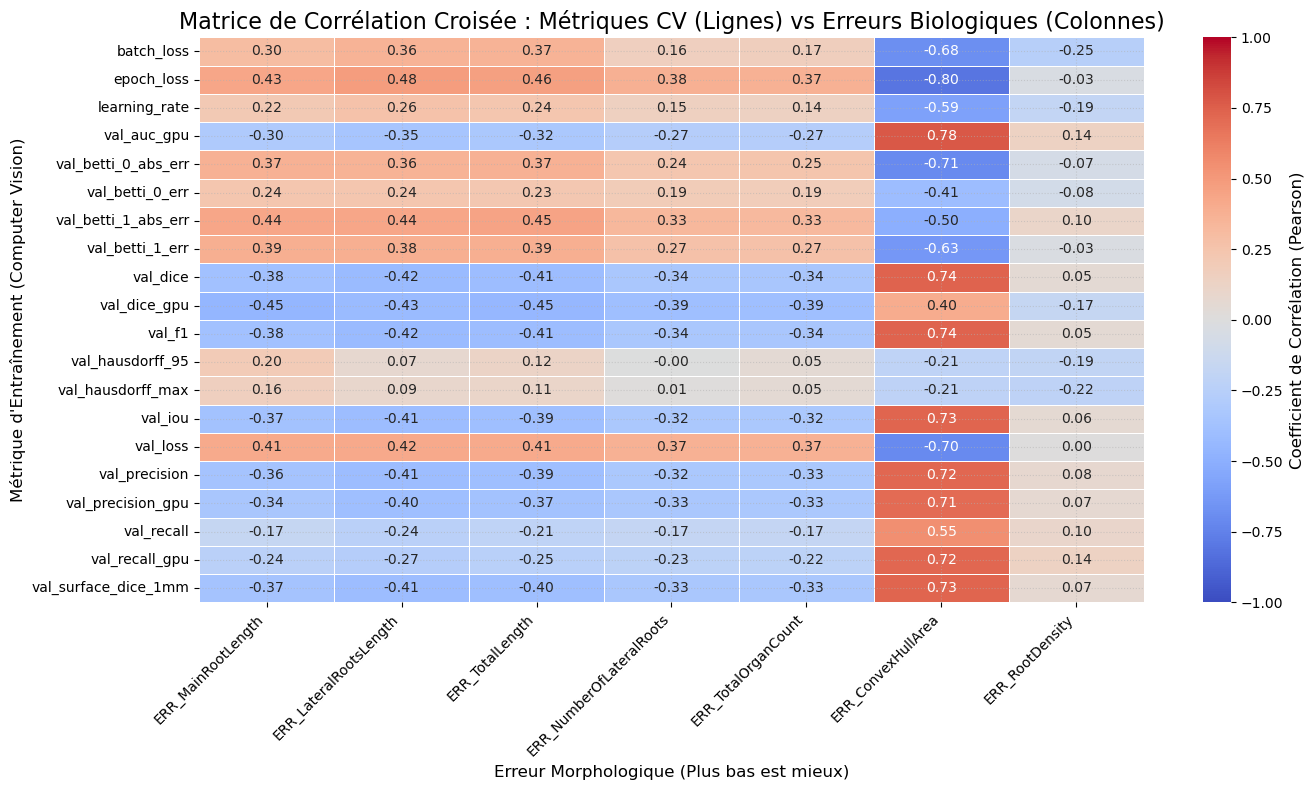

Données basées sur 120 points de comparaison (Loss/Epoch combinés).


In [15]:
import seaborn as sns

# ==========================================
# 1. PRÉPARATION ET AGRÉGATION
# ==========================================

# A. Préparation des données Morpho (Agrégation par Epoch & Loss)
# On calcule la moyenne des erreurs absolues pour toutes les plantes à chaque époque
morpho_cols = [c for c in df_diff.columns if c.startswith('abs_diff_')]
df_morpho_agg = df_diff.groupby(['loss_name', 'epoch'])[morpho_cols].mean().reset_index()

# On nettoie les noms de colonnes pour l'affichage (enlève 'abs_diff_')
rename_dict = {c: f"ERR_{c.replace('abs_diff_', '')}" for c in morpho_cols}
df_morpho_agg = df_morpho_agg.rename(columns=rename_dict)


# B. Préparation des données Logs (Pivot)
# On s'assure d'avoir le nom de la loss
try:
    df_logs['loss_name_extracted'] = df_logs['folder'].apply(lambda x: x.split('/')[-3])
except:
    df_logs['loss_name_extracted'] = "Unknown"

# On pivote pour avoir une colonne par métrique (loss, val_loss, dice, etc.)
# Note : df_logs a souvent des 'steps'. On va supposer ici que les steps correspondent aux epochs
# ou qu'il faut les aligner. Pour simplifier, on prend la dernière valeur par step/loss.
df_logs_pivot = df_logs.pivot_table(index=['loss_name_extracted', 'step'], 
                                    columns='metric', 
                                    values='value').reset_index()

# C. ALIGNEMENT DES EPOCHS (Partie Critique)
# Les logs ont des 'steps', la morpho a des 'epochs'. 
# On va tenter de mapper les steps uniques aux epochs uniques séquentiellement.

def align_epochs(group):
    # On trie les steps
    group = group.sort_values('step')
    # On récupère les époques disponibles dans la morpho pour cette loss
    available_epochs = sorted(df_morpho_agg[df_morpho_agg['loss_name'] == df_logs['loss_name_extracted'].iloc[0]]['epoch'].unique())
    
    # Si le nombre de points ne correspond pas exactement, on tronque au minimum commun
    min_len = min(len(group), len(available_epochs))
    if min_len == 0:
        return None
    
    # On assigne les époques aux steps (suppose que les logs sont pris aux mêmes moments)
    group = group.iloc[:min_len].copy()
    group['epoch'] = available_epochs[:min_len]
    return group

# Application de l'alignement par loss
df_logs_aligned = df_logs_pivot.groupby('loss_name_extracted').apply(align_epochs).reset_index(drop=True)

if df_logs_aligned.empty:
    print("ERREUR : Impossible d'aligner automatiquement les Steps des logs avec les Epochs de la morpho.")
    print("Vérifiez que vos noms de loss correspondent exactement entre les deux fichiers.")
else:
    # ==========================================
    # 2. FUSION ET CORRÉLATION
    # ==========================================

    # Fusion sur (loss_name, epoch)
    # df_logs_aligned a 'loss_name_extracted', df_morpho_agg a 'loss_name'
    merged_df = pd.merge(
        df_morpho_agg, 
        df_logs_aligned, 
        left_on=['loss_name', 'epoch'], 
        right_on=['loss_name_extracted', 'epoch']
    )

    # Sélection des colonnes numériques pour la corrélation
    # Colonnes Morpho (commencent par ERR_)
    cols_morpho = [c for c in merged_df.columns if c.startswith('ERR_')]
    # Colonnes Logs (tout le reste sauf les clés)
    cols_logs = [c for c in merged_df.columns if c not in cols_morpho and c not in ['loss_name', 'loss_name_extracted', 'epoch', 'step']]

    # Calcul de la matrice de corrélation
    corr_matrix = merged_df[cols_logs + cols_morpho].corr()

    # On extrait le sous-rectangle : Lignes = Métriques Logs, Colonnes = Erreurs Morpho
    # C'est ce croisement qui nous intéresse
    cross_corr = corr_matrix.loc[cols_logs, cols_morpho]

    # ==========================================
    # 3. VISUALISATION
    # ==========================================

    plt.figure(figsize=(14, 8))
    
    # Heatmap
    sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0,
                linewidths=.5, cbar_kws={'label': 'Coefficient de Corrélation (Pearson)'})
    
    plt.title("Matrice de Corrélation Croisée : Métriques CV (Lignes) vs Erreurs Biologiques (Colonnes)", fontsize=16)
    plt.xlabel("Erreur Morphologique (Plus bas est mieux)")
    plt.ylabel("Métrique d'Entraînement (Computer Vision)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f"Données basées sur {len(merged_df)} points de comparaison (Loss/Epoch combinés).")

Logs processed. Shape: (30339, 12)
Metrics found: ['val_precision', 'val_recall', 'val_iou', 'val_dice', 'val_betti_0_abs_err', 'val_betti_0_err', 'val_betti_1_abs_err', 'val_betti_1_err', 'val_hausdorff_95', 'val_hausdorff_max']
Data merged for correlation. Data points (Epochs x Losses): 117


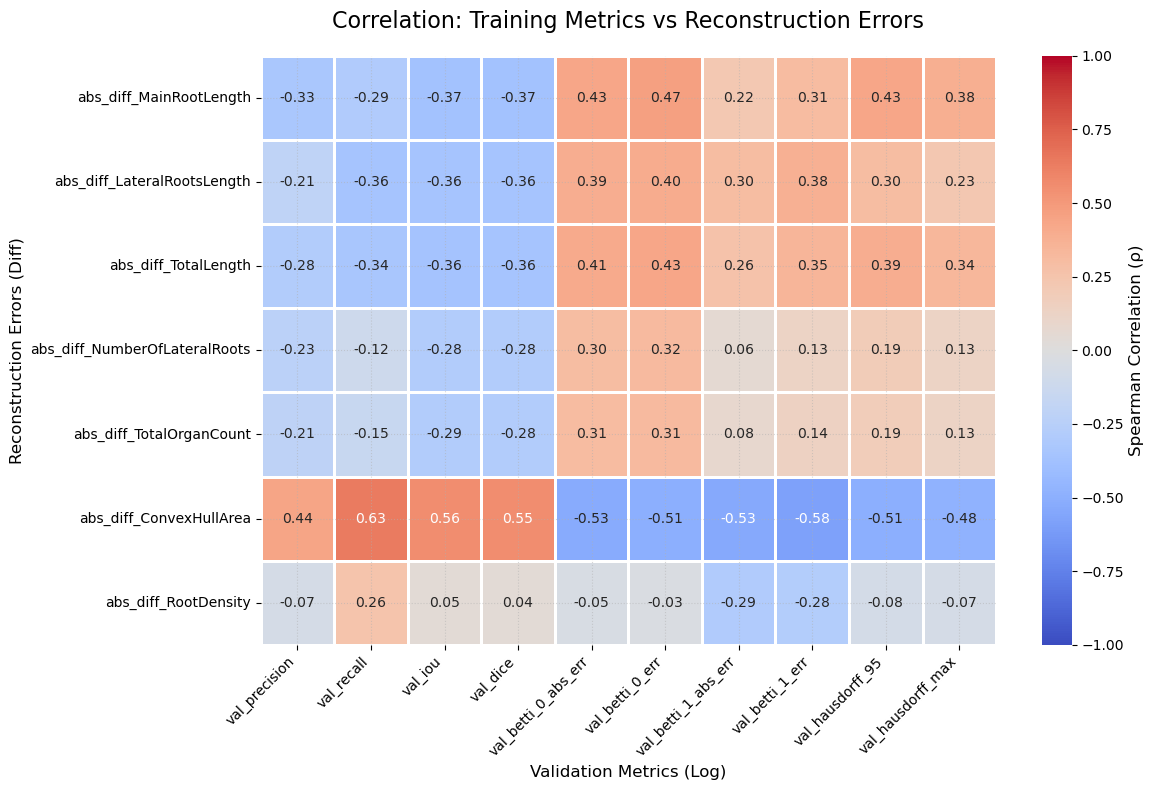

In [ ]:
import seaborn as sns
from scipy.stats import spearmanr

def clean_and_pivot_logs(df_logs_raw):
    df = df_logs_raw.copy()
    
    try:
        df['loss_name'] = df['folder'].apply(lambda x: x.split('/')[-3])
    except:
        print("Warning: Could not extract loss_name from folder. checking path structure...")
        return None


    if 'epoch' not in df.columns:
        if 'step' in df.columns:
            df['epoch'] = df['step'] 
        else:
            print("Error: No 'epoch' or 'step' column in logs.")
            return None

    df_pivot = df.pivot_table(index=['loss_name', 'epoch'], 
                              columns='metric', 
                              values='value', 
                              aggfunc='mean').reset_index()
    
    var_2_remove = ['batch_loss', 'learning_rate', 'epoch_loss', "val_auc_gpu", "val_dice_gpu", "val_precision_gpu", 'val_recall_gpu', 'val_f1', 'val_surface_dice_1mm', 'val_loss']
    for var in var_2_remove:
        if var in df_pivot.columns:
            df_pivot = df_pivot.drop(columns=[var])
    
    order_cols = []
    for var in ['val_precision', 'val_recall', 'val_iou', 'val_dice', 'val_haussdorff', 'val_haussdorf_95']:
        if var in df_pivot.columns:
            order_cols.append(var)
    for col in df_pivot.columns:
        if col not in order_cols and col not in ['loss_name', 'epoch']:
            order_cols.append(col)
    df_pivot = df_pivot[['loss_name', 'epoch'] + order_cols]
    
    return df_pivot

def plot_correlation_matrix(df_merged, x_cols, y_cols, title="Correlation Matrix (Spearman)"):

    corr_matrix = pd.DataFrame(index=y_cols, columns=x_cols)
    p_matrix = pd.DataFrame(index=y_cols, columns=x_cols)

    for y in y_cols:
        for x in x_cols:
            if x not in df_merged.columns or y not in df_merged.columns:
                continue
            
            sub = df_merged[[x, y]].dropna()
            if len(sub) < 2:
                rho, p = np.nan, np.nan
            else:
                rho, p = spearmanr(sub[x], sub[y])
            
            corr_matrix.loc[y, x] = rho
            p_matrix.loc[y, x] = p

    corr_matrix = corr_matrix.astype(float)

    plt.figure(figsize=(max(10, len(x_cols)*1.2), max(8, len(y_cols)*0.8)))
    
    ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", 
                     cmap="coolwarm", vmin=-1, vmax=1, center=0,
                     linewidths=1, linecolor='white',
                     cbar_kws={"label": "Spearman Correlation (ρ)"})
    
    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel("Validation Metrics (Log)", fontsize=12)
    ax.set_ylabel("Reconstruction Errors (Diff)", fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

df_logs_clean = clean_and_pivot_logs(df_logs)

if df_logs_clean is not None:
    print(f"Logs processed. Shape: {df_logs_clean.shape}")
    print(f"Metrics found: {[c for c in df_logs_clean.columns if c not in ['loss_name', 'epoch']]}")

    group_cols = ['loss_name', 'epoch']
    diff_metrics = [c for c in df_diff.columns if c.startswith('abs_diff_')]
    
    df_diff_grouped = df_diff.groupby(group_cols)[diff_metrics].mean().reset_index()

    df_corr = pd.merge(df_logs_clean, df_diff_grouped, on=['loss_name', 'epoch'], how='inner')
    
    print(f"Data merged for correlation. Data points (Epochs x Losses): {len(df_corr)}")
    
    if len(df_corr) > 2:

        log_metrics = [c for c in df_logs_clean.columns if c not in ['loss_name', 'epoch']]
        
      
        graph_error_metrics = diff_metrics
        
        plot_correlation_matrix(df_corr, 
                                x_cols=log_metrics, 
                                y_cols=graph_error_metrics,
                                title="Correlation: Training Metrics vs Reconstruction Errors")
        
    else:
        print("Not enough matching data points (Epochs/Losses) between Logs and Predictions to compute correlations.")
else:
    print("Log processing failed.")

Data merged. Total points: 117
Losses found: ['BCE' 'CLDICE' 'DICE']


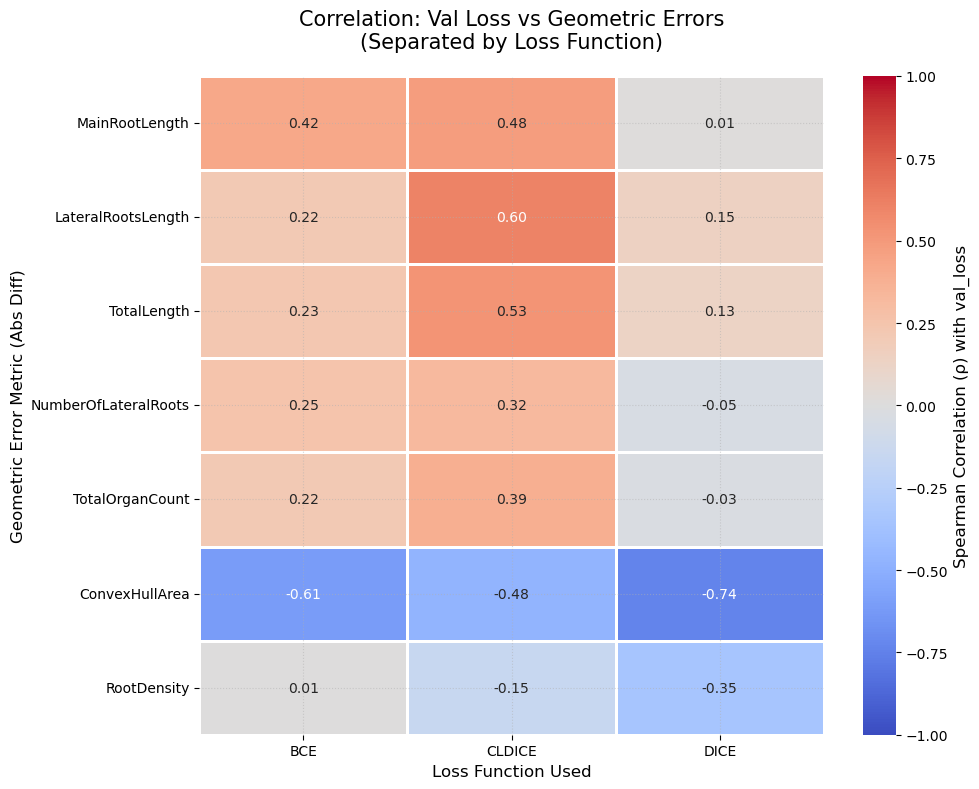

In [ ]:
import seaborn as sns
from scipy.stats import spearmanr

def plot_correlation_by_loss_type(df_logs, df_diff):
    df_val_loss = df_logs[df_logs['metric'] == 'val_loss'].copy()
    df_val_loss['loss_name_extracted'] = df_val_loss['folder'].apply(lambda x: x.split('/')[-3])
    if 'epoch' not in df_val_loss.columns and 'step' in df_val_loss.columns:
        df_val_loss['epoch'] = df_val_loss['step']
        
    df_val_loss = df_val_loss[['loss_name_extracted', 'epoch', 'value']].rename(columns={'value': 'val_loss'})
    
    df_val_loss = df_val_loss.groupby(['loss_name_extracted', 'epoch'])['val_loss'].mean().reset_index()

    diff_cols = [c for c in df_diff.columns if c.startswith('abs_diff_')]
    df_diff_grouped = df_diff.groupby(['loss_name', 'epoch'])[diff_cols].mean().reset_index()

    df_merged = pd.merge(
        df_val_loss, 
        df_diff_grouped, 
        left_on=['loss_name_extracted', 'epoch'],
        right_on=['loss_name', 'epoch'],
        how='inner'
    )
    
    print(f"Data merged. Total points: {len(df_merged)}")
    print(f"Losses found: {df_merged['loss_name'].unique()}")

    unique_losses = sorted(df_merged['loss_name'].unique())
    results_rho = pd.DataFrame(index=diff_cols, columns=unique_losses)
    results_p = pd.DataFrame(index=diff_cols, columns=unique_losses)

    for loss in unique_losses:
        sub = df_merged[df_merged['loss_name'] == loss]
        
        for metric in diff_cols:
            clean_sub = sub[['val_loss', metric]].dropna()
            
            if len(clean_sub) < 3: 
                rho, p = np.nan, np.nan
            else:
                rho, p = spearmanr(clean_sub['val_loss'], clean_sub[metric])
            
            results_rho.loc[metric, loss] = rho
            results_p.loc[metric, loss] = p

    results_rho = results_rho.astype(float)

    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(results_rho, annot=True, fmt=".2f", 
                     cmap="coolwarm", vmin=-1, vmax=1, center=0,
                     linewidths=1, linecolor='white',
                     cbar_kws={"label": "Spearman Correlation (ρ) with val_loss"})
    
    ax.set_title("Correlation: Val Loss vs Geometric Errors\n(Separated by Loss Function)", fontsize=15, pad=20)
    ax.set_xlabel("Loss Function Used", fontsize=12)
    ax.set_ylabel("Geometric Error Metric (Abs Diff)", fontsize=12)
    
    yticklabels = [lbl.get_text().replace('abs_diff_', '') for lbl in ax.get_yticklabels()]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return results_rho

# Exécution
rho_matrix = plot_correlation_by_loss_type(df_logs, df_diff)

/home/loai/miniforge3/envs/utils/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4734: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean
/home/loai/miniforge3/envs/utils/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4734: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean
/home/loai/miniforge3/envs/utils/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4734: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean
/home/loai/miniforge3/envs/utils/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4734: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean
/home/loai/miniforge3/envs/utils/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4734: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean
/home/loai/miniforge3/envs/utils/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4734: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean
/home/loai/minif

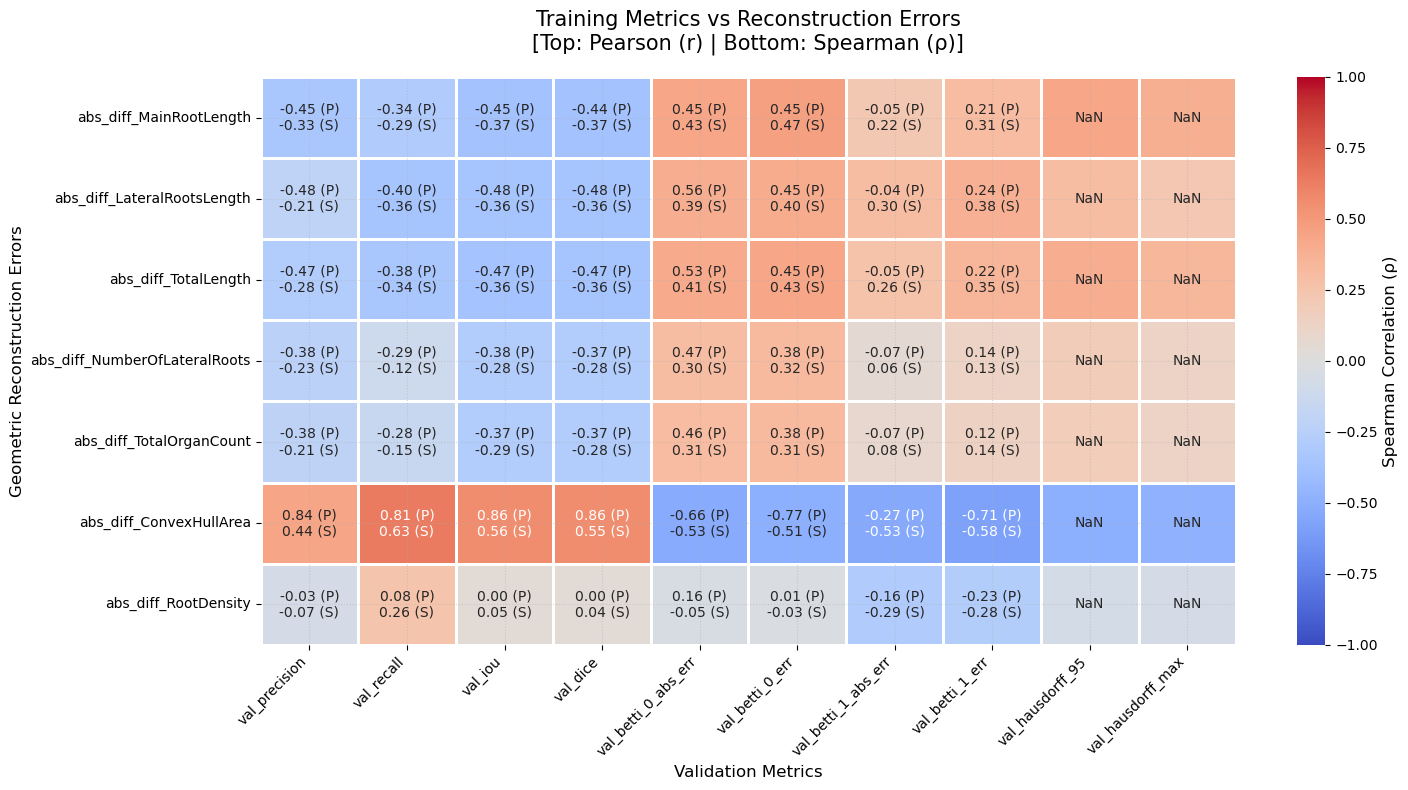

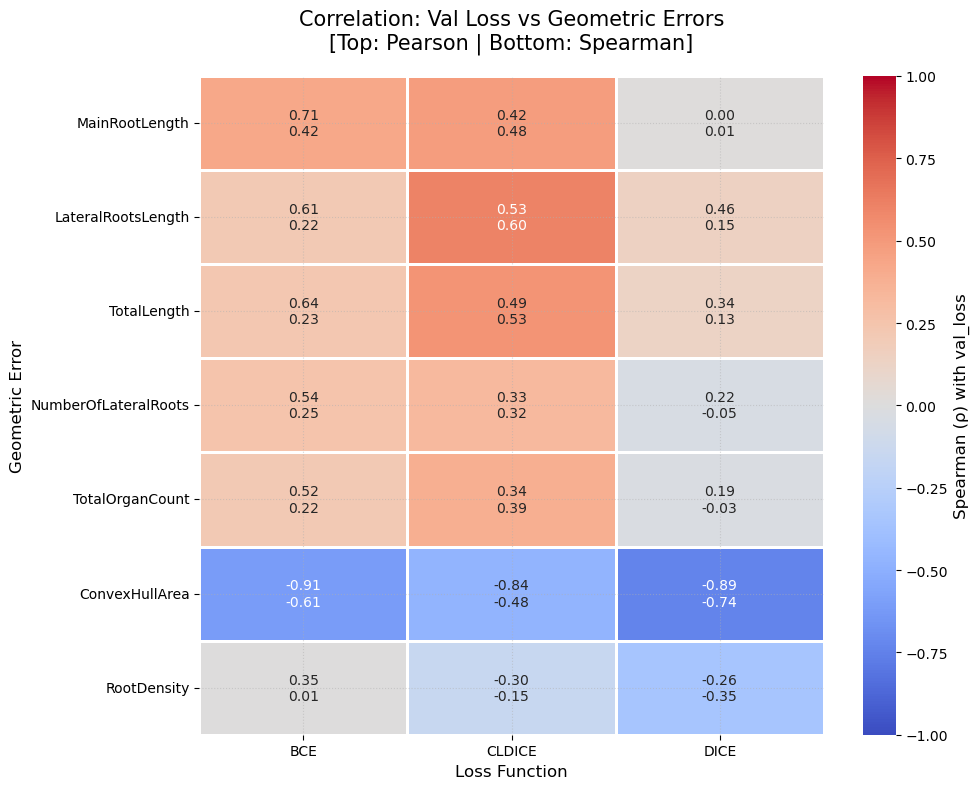

In [ ]:
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def clean_and_pivot_logs(df_logs_raw):
    df = df_logs_raw.copy()
    
    try:
        df['loss_name'] = df['folder'].apply(lambda x: x.split('/')[-3])
    except:
        print("Warning: Could not extract loss_name from folder.")
        return None

    if 'epoch' not in df.columns:
        if 'step' in df.columns:
            df['epoch'] = df['step'] 
        else:
            print("Error: No 'epoch' or 'step' column in logs.")
            return None

    df_pivot = df.pivot_table(index=['loss_name', 'epoch'], 
                              columns='metric', 
                              values='value', 
                              aggfunc='mean').reset_index()
    
    var_2_remove = ['batch_loss', 'learning_rate', 'epoch_loss', "val_auc_gpu", 
                    "val_dice_gpu", "val_precision_gpu", 'val_recall_gpu', 
                    'val_f1', 'val_surface_dice_1mm', 'val_loss']
    
    for var in var_2_remove:
        if var in df_pivot.columns:
            df_pivot = df_pivot.drop(columns=[var])
    
    order_cols = []
    preferred_order = ['val_precision', 'val_recall', 'val_iou', 'val_dice', 
                       'val_haussdorff', 'val_haussdorf_95']
    
    for var in preferred_order:
        if var in df_pivot.columns:
            order_cols.append(var)
    for col in df_pivot.columns:
        if col not in order_cols and col not in ['loss_name', 'epoch']:
            order_cols.append(col)
            
    df_pivot = df_pivot[['loss_name', 'epoch'] + order_cols]
    
    return df_pivot

def plot_correlation_matrix(df_merged, x_cols, y_cols, title="Correlation Matrix"):
    """
    Génère la heatmap avec Pearson et Spearman.
    Couleur de la case = Spearman (plus robuste aux outliers).
    Texte = Pearson \n Spearman.
    """
    # Matrices pour la couleur (float) et le texte (string)
    corr_matrix_color = pd.DataFrame(index=y_cols, columns=x_cols, dtype=float)
    annot_matrix = pd.DataFrame(index=y_cols, columns=x_cols, dtype=object)

    for y in y_cols:
        for x in x_cols:
            if x not in df_merged.columns or y not in df_merged.columns:
                continue
            
            sub = df_merged[[x, y]].dropna()
            if len(sub) < 2:
                rho, r = np.nan, np.nan
            else:
                rho, _ = spearmanr(sub[x], sub[y]) # Spearman
                r, _ = pearsonr(sub[x], sub[y])    # Pearson
            
            # On utilise Spearman pour la couleur de fond (souvent préféré en métrologie)
            corr_matrix_color.loc[y, x] = rho
            
            # Annotation: Pearson en haut, Spearman en bas
            if pd.notna(r) and pd.notna(rho):
                annot_matrix.loc[y, x] = f"{r:.2f} (P)\n{rho:.2f} (S)"
            else:
                annot_matrix.loc[y, x] = "NaN"

    plt.figure(figsize=(max(12, len(x_cols)*1.5), max(8, len(y_cols)*0.9)))
    
    ax = sns.heatmap(corr_matrix_color, annot=annot_matrix, fmt="", 
                     cmap="coolwarm", vmin=-1, vmax=1, center=0,
                     linewidths=1, linecolor='white',
                     cbar_kws={"label": "Spearman Correlation (ρ)"})
    
    ax.set_title(f"{title}\n[Top: Pearson (r) | Bottom: Spearman (ρ)]", fontsize=15, pad=20)
    ax.set_xlabel("Validation Metrics", fontsize=12)
    ax.set_ylabel("Reconstruction Errors", fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --- 1. Préparation et Exécution du premier plot ---
df_logs_clean = clean_and_pivot_logs(df_logs)

if df_logs_clean is not None:
    # Merge avec les différences géométriques
    group_cols = ['loss_name', 'epoch']
    diff_metrics = [c for c in df_diff.columns if c.startswith('abs_diff_')]
    
    df_diff_grouped = df_diff.groupby(group_cols)[diff_metrics].mean().reset_index()
    df_corr = pd.merge(df_logs_clean, df_diff_grouped, on=['loss_name', 'epoch'], how='inner')
    
    if len(df_corr) > 2:
        log_metrics = [c for c in df_logs_clean.columns if c not in ['loss_name', 'epoch']]
        
        plot_correlation_matrix(
            df_corr, 
            x_cols=log_metrics, 
            y_cols=diff_metrics,
            title="Training Metrics vs Reconstruction Errors"
        )
    else:
        print("Not enough data for correlation.")

# %% [markdown]
# ### Correlation Matrix: Separated by Loss Function (Dual Metrics)

# %%
def plot_correlation_by_loss_type_dual(df_logs, df_diff):
    # --- Préparation ---
    # Extraction propre de val_loss
    df_val_loss = df_logs[df_logs['metric'] == 'val_loss'].copy()
    df_val_loss['loss_name_extracted'] = df_val_loss['folder'].apply(lambda x: x.split('/')[-3])
    
    if 'epoch' not in df_val_loss.columns and 'step' in df_val_loss.columns:
        df_val_loss['epoch'] = df_val_loss['step']
        
    df_val_loss = df_val_loss[['loss_name_extracted', 'epoch', 'value']].rename(columns={'value': 'val_loss'})
    df_val_loss = df_val_loss.groupby(['loss_name_extracted', 'epoch'])['val_loss'].mean().reset_index()

    diff_cols = [c for c in df_diff.columns if c.startswith('abs_diff_')]
    df_diff_grouped = df_diff.groupby(['loss_name', 'epoch'])[diff_cols].mean().reset_index()

    df_merged = pd.merge(
        df_val_loss, 
        df_diff_grouped, 
        left_on=['loss_name_extracted', 'epoch'],
        right_on=['loss_name', 'epoch'],
        how='inner'
    )
    
    # --- Calcul ---
    unique_losses = sorted(df_merged['loss_name'].unique())
    
    # Matrices
    corr_matrix_color = pd.DataFrame(index=diff_cols, columns=unique_losses, dtype=float)
    annot_matrix = pd.DataFrame(index=diff_cols, columns=unique_losses, dtype=object)

    for loss in unique_losses:
        sub = df_merged[df_merged['loss_name'] == loss]
        for metric in diff_cols:
            clean_sub = sub[['val_loss', metric]].dropna()
            
            if len(clean_sub) < 3:
                rho, r = np.nan, np.nan
            else:
                rho, _ = spearmanr(clean_sub['val_loss'], clean_sub[metric])
                r, _ = pearsonr(clean_sub['val_loss'], clean_sub[metric])
            
            corr_matrix_color.loc[metric, loss] = rho
            if pd.notna(r) and pd.notna(rho):
                annot_matrix.loc[metric, loss] = f"{r:.2f}\n{rho:.2f}"
            else:
                annot_matrix.loc[metric, loss] = ""

    # --- Plot ---
    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(corr_matrix_color, annot=annot_matrix, fmt="", 
                     cmap="coolwarm", vmin=-1, vmax=1, center=0,
                     linewidths=1, linecolor='white',
                     cbar_kws={"label": "Spearman (ρ) with val_loss"})
    
    ax.set_title("Correlation: Val Loss vs Geometric Errors\n[Top: Pearson | Bottom: Spearman]", fontsize=15, pad=20)
    ax.set_xlabel("Loss Function", fontsize=12)
    ax.set_ylabel("Geometric Error", fontsize=12)
    
    # Clean Y labels
    yticklabels = [lbl.get_text().replace('abs_diff_', '') for lbl in ax.get_yticklabels()]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.tight_layout()
    plt.show()

# Exécution
plot_correlation_by_loss_type_dual(df_logs, df_diff)